<h1>Clustering and association rule mining</h1>

<h2>1. Business understanding</h2>

*Original assignment: https://github.com/vesavvo/dkko/blob/main/assignments/Assignment_Clustering_and_association_rule_mining.md*

Our first task is to increase the efficiency of drone based delivery operations by finding out the optimal way to space out company's drone hubs. Additionally, we aim to increase revenue by more accurately recommend products to their respective target groups. These studies will be done based on two datasets, containing the location of the customers https://github.com/vesavvo/dkko/blob/main/datasets/drone_delivery/drone_cust_locations.csv and the sales data of products https://github.com/vesavvo/dkko/blob/main/datasets/drone_delivery/drone_prod_groups.csv.

This pipeline uses clustering and association rule mining to map out major client groups by distance of travel, and to find meaningful relationships between products that are frequently purchased together. Our expected outcome contains optimal locations for drone bases and any significant grouping products frequently bought together.

<h2>2. Data understanding</h2>

We will first study our data to better understand what it contains, how it is stored and whether it has any quality issues that needs to be taken into account. We will start from the dataset containing the location of customers.

In [148]:
import pandas as pd

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# loads location data
loc_df = []
with open('../datasets/drone_cust_locations.csv', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        loc_df.append(line.split(';'))

# assigns correct column names
names = ['clientid', 'x', 'y']
loc_df = pd.DataFrame(loc_df[1:], columns=names)

loc_df

,clientid,x,y
0,1,622.7715723,164.8576227
1,2,416.3572979,630.1936343
2,3,292.7350197,567.3332306
3,4,737.2112881,166.2256759
4,5,540.4753747,682.912298
...,...,...,...
5951,5952,832.8573939,616.8614096
5952,5953,242.7345004,490.3250925
5953,5954,108.6908474,758.8339212
5954,5955,803.2510739,430.7406227


Besides client's id, data contains x and y-coordinates which we will be using to map our clients' locations. We will also check their datatypes.

In [151]:
loc_df.dtypes

clientid    object
x           object
y           object
dtype: object

To better handle coordinates, we will change them to floats.

In [154]:
loc_df['x'] = loc_df['x'].astype('Float64')
loc_df['y'] = loc_df['y'].astype('Float64')
loc_df.dtypes

clientid     object
x           Float64
y           Float64
dtype: object

Finally, we will check data for missing values.

In [157]:
print(loc_df.isna().sum())

clientid    0
x           0
y           0
dtype: int64


We will then perform same checks and operations to the other dataset containing sales data for products.

In [160]:
# loads product data
prod_df = []
with open('../datasets/drone_prod_groups.csv', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        prod_df.append(line.split(','))

# assigns correct column names
names = ['ID', 'Prod1', 'Prod2', 'Prod3', 'Prod4', 
         'Prod5', 'Prod6', 'Prod7', 'Prod8', 'Prod9', 
         'Prod10', 'Prod11', 'Prod12', 'Prod13', 'Prod14', 
         'Prod15', 'Prod16', 'Prod17', 'Prod18', 'Prod19', 
         'Prod20']
prod_df = pd.DataFrame(prod_df[1:], columns=names)

prod_df

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,99997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
99997,99998,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
99998,99999,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1


**ID** designates individual transactions and **Prod1**, ..., **Prod20** specific products that were purchased in the transations. The data does not indicate the amount bought, **0** means no product was bought in that transaction, **1** means that at least one product was bought in that transaction.

In [162]:
prod_df.dtypes

ID        object
Prod1     object
Prod2     object
Prod3     object
Prod4     object
Prod5     object
Prod6     object
Prod7     object
Prod8     object
Prod9     object
Prod10    object
Prod11    object
Prod12    object
Prod13    object
Prod14    object
Prod15    object
Prod16    object
Prod17    object
Prod18    object
Prod19    object
Prod20    object
dtype: object

In [163]:
# We will change value types from str to int
prod_df = prod_df.astype('int64')

# We also check for missing values
print(prod_df.isna().sum())

ID        0
Prod1     0
Prod2     0
Prod3     0
Prod4     0
Prod5     0
Prod6     0
Prod7     0
Prod8     0
Prod9     0
Prod10    0
Prod11    0
Prod12    0
Prod13    0
Prod14    0
Prod15    0
Prod16    0
Prod17    0
Prod18    0
Prod19    0
Prod20    0
dtype: int64


Dataset does not contain any missing values and its types are now more suited for further preparation and study.

<h2>3. Data preparation</h2>

As we will be using clustering to study the dataset and there are no target values to predict, we do not need to divide data into training and testing data. Same applies to association rule mining.

In both cases we need to drop the ID values, as k-means would treat it as a meaningful datapoint. With association rule mining, id is not a product that should be taken into account and is also dropped.

In [170]:
loc_df = loc_df.drop(columns=['clientid'])
prod_df = prod_df.drop(columns=['ID'])

As neither dataset contained empty values or differences in scale, we can continue to modeling the data.

<h2>4. Modeling</h2>

 - Valitaan koneoppimismenetelmä, opetetaan malli ja validoidaan se (validation).
 - Dokumentointiin on sisällytettävä tarkasti valittu menetelmä, käytetyt parametrit sekä mitattu mallin suorituskyky.
 - Millä perusteella tehty valinnat
 - Taulukko on hyvä viestimiseen
 - Ei tarvitse olla yksityiskohtainen, mutta selitetään miksi on päädytty lopputulokseen.

We will visualize the location data by creating a two-dimensional scatterplot using `scatter` function from `Matplotlib` library. It is important to note that the coordinates presented are not real world coordinates, but coordinates when plotted into a 2D plane.

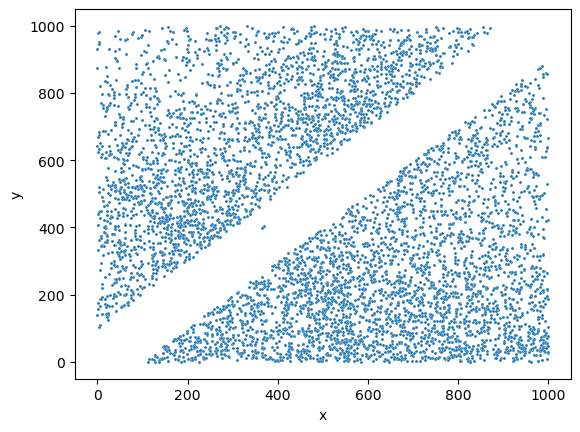

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=loc_df, x='x', y='y', s=5)

plt.xlabel('x')
plt.ylabel('y')
plt.show()

From the scatter plot above, we can see that the data is separated into two clearly distinguishable areas. There is a diagonal gap between the two areas, which could suggest that the clients are located in two separate regions. That could mean it is a body of water, mountains or country border?

In [520]:
from sklearn.cluster import KMeans

#how many depopts for drones we would like to test
CENTROID_AMOUNT = 5

model = KMeans(n_clusters=CENTROID_AMOUNT, n_init='auto', random_state=42)
model.fit(loc_df)

l = model.labels_

# Print centroid coordinates (this are the locations of each drone delivery base)
print('DEPOT [X, Y] COORDINATES\n')
print(model.cluster_centers_)

DEPOT [X, Y] COORDINATES

[[157.83377433 459.28006561   1.        ]
 [439.08909318 148.65179928   2.        ]
 [767.32467697 703.3695577    3.0055991 ]
 [379.43398826 798.4350836    3.99463327]
 [800.95055182 201.17734323   4.99720865]]


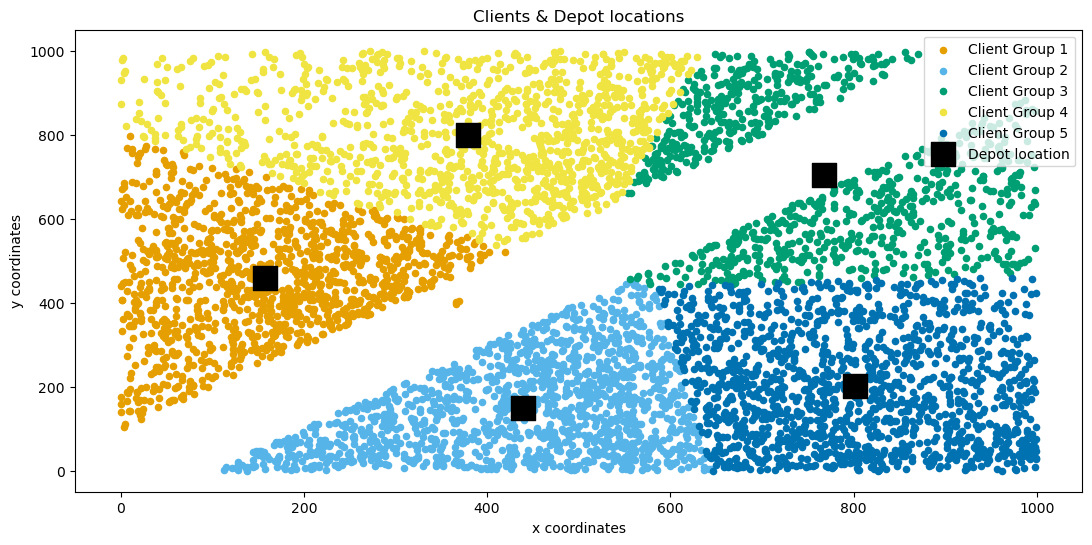

In [542]:
def visualize_kmeans(centroid_amount):
    # "Okabe–Ito palette", a great palatte for color blind people.
    colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
    plt.figure(figsize=(13, 6))
    
    coordinates = loc_df[['x', 'y']].values
    lbls = model.labels_

    for i in range(centroid_amount):
        cluster_points = coordinates[lbls == i]
     
        if i < len(colors): #default state if the hard coded colours are enough
            color = colors[i]
            
            plt.scatter(
                cluster_points[:, 0],
                cluster_points[:, 1],
                color=color,
                s=20,
                label=f'Client Group {i+1}'
            )       
        else: #if we run out of hard coded colors
            plt.scatter(
                cluster_points[:, 0],
                cluster_points[:, 1],
                s=20,
                label=f'Client Group {i+1}'
            ) 

    #visualize centroids
    plt.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        color='black',
        marker='s',
        s=300,
        label='Depot location'
    )

    
    plt.xlabel('x coordinates')
    plt.ylabel('y coordinates')
    plt.title('Clients & Depot locations')
    plt.legend()
    plt.show()

visualize_kmeans(CENTROID_AMOUNT)

Above, we can see the visualized locations for the depots alongside the customer clusters in five different colors. The model has divided the customers into five distinct groups, placing two depots in the upper-left region and three in the lower-right region.   

However, looking at the green group (Client Group 3) in the top-right, its depot location looks a bit odd as it sits right along the edge near the unpopulated diagonal zone. Before making final operational decisions, we should consider what lies in this middle gap (e.g., a river or highway) and whether edge clients would practically be better served by a neighboring depot rather than relying strictly on Euclidean distance.

In [544]:
#add 'Depot_ID' column, indicatig the nearest depot
loc_df["Depot_ID"] = l + 1
loc_df.head(10)

,x,y,Depot_ID
0,622.771572,164.857623,5
1,416.357298,630.193634,4
2,292.73502,567.333231,1
3,737.211288,166.225676,5
4,540.475375,682.912298,4
5,535.469492,318.439661,2
6,640.38005,870.833221,3
7,235.772075,359.048203,1
8,481.896884,661.491838,4
9,730.032789,312.177817,5


The first 10 rows on the above table is displayed and nearest asigned depot is added to the data frame.

<h2>5. Evaluation</h2>

 - Arvioidaan mallin todellinen onnistuminen.
 - Selvitetään, kuinka hyvin malli vastaa sille alun perin asetettuihin liiketoimintavaatimuksiin (business requirements).<br>
 - Ei katsota mallin suorituskykyä (tämä tehdään kappaleessa 4), vaan palataan takaisin kappaleeseen 1. ja millä tavalla saavutetut tulokset vertautuu alkuperäisiin tavoitteisiin.

In [ ]:
wcss = []

for i in range(1,11):
    model = KMeans(init='random', n_clusters=i, n_init='auto', random_state=42).fit(loc_df[['x', 'y']])
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

According to the elbow rule, the optimal depot amount could be somewhere between 3-5.

In [ ]:
from sklearn.metrics import silhouette_score

# input val
X = loc_df[['x', 'y']]

# define what amount ofdepots we would like to test
k_values = [2, 3, 4, 5, 6, 7, 8, 10, 16]
results = []

for k in k_values:
    # model init
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    
    # calculate silhouette score
    score = silhouette_score(X, labels)
    
    # save/append the score
    results.append({
        'k (Depot amount)': k,
        'Silhouette Score': round(score, 4)
    })

# turn to pandas dataframe and print results
silhouette_df = pd.DataFrame(results)
silhouette_df

In the table above, we can see the silhouette scores for different numbers of depots. The highest scores were achieved by $k$ values of 2 and 3, which means that customer groups divide most cleanly into two or three regions. The silhouette score starts decreasing gradually after $k=5$, showing that dividing clients into more than 5 regions creates less distinct clusters.

While two or three depots would be mathematically most optimal, increasing the number of depots to 5 would likely be the best practical decision. Drones have limited range and need to recharge, so having 5 depots allows them to serve customers much more efficiently.

<h2>6. Deployment</h2>

- Malli viedään käytäntöön (deployment).
- Tähän sisältyy tulosten viestiminen ja suositusten luominen siitä, miten mallia tulisi hyödyntää käytännössä tai mitä jatkotoimenpiteitä tulisi tehdä.